# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados  
**Grupo:** 
Davi Oliveira Sad - 2023096043 <br>
Gabrielly Xavier dos Santos - 2024023724 <br>
Júlia Luíza Costa de Toledo - 2024008431 <br>
Rafael Vinicius de Sant’Ana Mathias - 2023087834 <br> 
**Dataset:** Mushroom    
**Tarefa de mineração:** Classificação   
**Data da entrega:** 21/06/2026 

---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo deve:

1. corrigir erros e limitações identificados na Fase 2;
2. consolidar a solução técnica efetivamente implementada;
3. executar a modelagem final;
4. avaliar criticamente os resultados;
5. comparar três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

> **Importante:** este notebook é um modelo. Ele contém placeholders e trechos de código genéricos. O grupo deve adaptar tudo ao dataset, à tarefa e às decisões reais tomadas no trabalho.

# Como usar este notebook

Este notebook foi estruturado para orientar uma boa entrega final, sem substituir o trabalho do grupo.

Use os campos marcados como:

- `[INSERIR ...]`
- `[DESCREVER ...]`
- `[JUSTIFICAR ...]`
- `[ANALISAR ...]`
- `[PREENCHER ...]`

como indicações de conteúdo que deve ser produzido pelo grupo.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs.

Na Fase 3, o foco passa a ser a **solução final consolidada**, isto é:

- quais sugestões da LLM foram incorporadas;
- quais foram corrigidas;
- quais foram rejeitadas;
- quais algoritmos e parâmetros foram realmente usados;
- quais resultados foram efetivamente obtidos;
- como os resultados se relacionam ao problema de negócio e às diretrizes de IA responsável.

Não é necessário repetir todos os links completos das conversas da Fase 2, mas a comparação entre baseline, guiada e solução final deve permanecer clara.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
| :--- | :--- |
| **Nome do dataset** | Mushroom Dataset (Agaricus and Lepiota) |
| **Link público do dataset** | https://archive.ics.uci.edu/dataset/73/mushroom |
| **Número de linhas** | 8.124 |
| **Número de colunas** | 22 atributos preditivos + 1 variável-alvo |
| **Tarefa de mineração** | Classificação |
| **Diretriz 1 de IA responsável** | Segurança, confiabilidade e robustez |
| **Diretriz 2 de IA responsável** | Transparência e explicabilidade |
| **LLM usada na Fase 2 — baseline** | Google Gemini |
| **LLM usada na Fase 2 — guiada** | Google Gemini |
| **Notebook da Fase 2** | https://github.com/DaviOSad/Mushroom-Classification/blob/main/TP3_Fase2_Grupo11.ipynb |

## Resumo das decisões herdadas da Fase 2

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
| :--- | :---: | :---: | :--- |
| **Exclusão de modelos Caixa-Preta** (*Random Forest*) | Trilha B | **Sim** | Modelos ensemble violam a diretriz de Transparência. Mantivemos apenas modelos "caixa-branca" para permitir auditoria direta das regras preditivas. |
| **Não-imputação de dados faltantes** na coluna `stalk-root` | Trilha B | **Sim** | Preencher as interrogações `?` com a moda inventaria dados e geraria correlações falsas e perigosas, violando a diretriz de Segurança. |
| **Uso exclusivo de One-Hot Encoding** | Grupo / Corrigido da Trilha A | **Sim** | Evita que o algoritmo interprete ordens e distâncias inexistentes na biologia (Label Encoding), preservando a semântica nominal correta. |
| **Calibração de Limiar de Decisão em 0.02** | Trilha B | **Sim** | Decisão mestre do projeto. Joga a fronteira de decisão a favor da preservação da vida, garantindo o Recall de 100% (zero Falsos Negativos). |
| **Ajuste de Penalização** (`class_weight`) para 20 | Grupo / Refinado da Trilha B | **Sim** | Reduzimos a sugestão inicial de 50 para 20. O teste empírico provou que o limiar de 0.02 absorve o impacto e mantém o Recall em 100%, diminuindo alarmes falsos. |
| **Restrição de nós folhas** (`min_samples_leaf=1%`) | Trilha B | **Sim** | Mantivemos a exigência de que cada folha tenha ao menos 1% das amostras. Isso evita que a árvore crie regras baseadas em ruídos estatísticos ou exceções raras, garantindo a generalização e robustez. |

In [2]:
# Configurações iniciais
# Esta célula centraliza imports, caminhos e parâmetros gerais do notebook.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = "agaricus-lepiota.data"

TASK_TYPE = "classificacao"

# Coluna-alvo que indica a edibilidade (e/p).
TARGET_COLUMN = "class"

TRANSACTION_COLUMN = None

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE = {TASK_TYPE}")
print(f"DATA_PATH = {DATA_PATH}")
print(f"TARGET_COLUMN = {TARGET_COLUMN}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

Configuração inicial carregada.
TASK_TYPE = classificacao
DATA_PATH = agaricus-lepiota.data
TARGET_COLUMN = class
OUTPUT_DIR = outputs


# 1. Business Understanding

Nesta seção, o grupo deve consolidar a compreensão do problema, incorporando eventuais correções feitas após a Fase 2.

A versão final deve responder:

1. Qual problema será investigado?
2. Por que o dataset é adequado para esse problema?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da solução?
5. Quais diretrizes de IA responsável foram consideradas?
6. Como essas diretrizes influenciaram a solução final?
7. Quais limitações permanecem mesmo após a consolidação da solução?

## 1.1 Problema de negócio e objetivo analítico

- **Contexto:** A identificação correta de cogumelos é uma tarefa crítica de segurança alimentar. Em situações de campo, um erro de classificação pode levar ao consumo acidental de uma espécie tóxica, com consequências graves para a saúde humana.

- **Problema:** O objetivo deste trabalho é construir um classificador capaz de distinguir cogumelos comestíveis de venenosos a partir de características morfológicas e ecológicas. Como todas as variáveis da base são categóricas, a tarefa exige codificação adequada e avaliação cuidadosa do modelo para reduzir ao máximo os falsos negativos, isto é, casos em que um cogumelo venenoso seria classificado como comestível.

- **Possíveis interessados:** Consumidores, micologistas, profissionais de saúde, órgãos de vigilância sanitária e desenvolvedores de aplicativos de apoio à identificação de espécies.

- **Decisões apoiadas pela análise:** O modelo pode apoiar triagens iniciais de segurança, orientar guias de identificação, auxiliar aplicativos de consulta em campo e servir como ferramenta educacional para reconhecer padrões associados à toxicidade.

- **Limitações iniciais conhecidas:** A base é composta apenas por atributos nominais, não contém medições laboratoriais e descreve apenas uma fração da diversidade de cogumelos existente. Além disso, o atributo stalk-root possui valores ausentes representados por '?', o que exige tratamento específico antes da modelagem.

### Ajustes em relação à Fase 2

O problema central e o objetivo analítico foram mantidos. No entanto, o escopo da modelagem foi refinado. Na concepção inicial, o objetivo era puramente preditivo (equilíbrio estatístico e maximização de métricas globais). Após a Fase 2, o escopo passou a integrar travas de segurança ativas: percebemos que não basta classificar a edibilidade de forma genérica; é imperativo garantir que o modelo não gere falsos negativos catastróficos (risco fatal à saúde) e não penalize excessivamente a precisão de espécimes comestíveis por excesso de zelo matemático (ajuste de sensibilidade através da calibração do peso de classe em 20 e fixação do limiar preventivo de risco em 0.02).

## 1.2 Dataset, origem e características gerais

### Identificação do dataset

- **Nome:** Mushroom Dataset (Agaricus and Lepiota)
- **Fonte:** UCI Machine Learning Repository (Original do Audubon Society Field Guide - 1981)
- **Link público:** https://archive.ics.uci.edu/dataset/73/mushroom
- **Data de acesso ou download:** 05/06/2026

### Características gerais

| Aspecto | Descrição |
|---|---|
| **O que cada linha representa?** | Um espécime isolado de cogumelo coletado com suas propriedades morfológicas e ecológicas registradas. |
| **O que cada coluna representa?** | Atributos físicos observáveis do fungo ou dados sobre o ambiente onde ele prolifera. |
| **Número de instâncias** | 8.124 linhas |
| **Número de atributos** | 22 atributos preditivos + 1 variável-alvo (23 colunas originais) |
| **Tipos principais de atributos** | Estritamente categóricos e nominais (representados por códigos de letras). |
| **Existe variável-alvo?** | Sim. A coluna `class`, indicando se o espécime é comestível (`e`) ou venenoso (`p`). |
| **Existem atributos sensíveis ou identificadores?** | Não. Por se tratar de uma base de dados estritamente botânica, não há registros de dados pessoais ou sensíveis. |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
| :--- | :--- | :--- | :---: | :--- |
| `class` | Categórica | Edibilidade do cogumelo: comestível (`e`) ou venenoso (`p`). | **ALVO** | Variável-alvo binária da tarefa de classificação. |
| `cap-shape` | Categórica | Formato do chapéu (sino, cônico, convexo, plano, afundado, saliente). | Feature | Atributo morfológico visual inicial. |
| `cap-surface` | Categórica | Superfície do chapéu (fibrosa, sulcada, escamosa, lisa). | Feature | Complemento da análise estrutural externa. |
| `cap-color` | Categórica | Cor do chapéu (marrom, bege, cinza, branco, amarelo etc.). | Feature | Mapeamento cromático (10 categorias distintas). |
| `bruises?` | Categórica | Indica presença (`t`) ou ausência (`f`) de manchas/hematomas. | Feature | Atributo binário de fácil verificação em campo. |
| `odor` | Categórica | Aroma exalado (amêndoa, anis, creosoto, fétido, nenhum, pungente etc.). | Feature | O atributo de maior ganho de informação para a tarefa. |
| `gill-attachment` | Categórica | Tipo de fixação das lâminas no caule. | Feature | Caracterização da anatomia interna do fungo. |
| `gill-spacing` | Categórica | Espaçamento entre as lâminas (fechado, aglomerado, distante). | Feature | Indicador taxonômico estrutural. |
| `gill-size` | Categórica | Tamanho das lâminas (largo ou estreito). | Feature | Diferenciação morfológica dicotômica. |
| `gill-color` | Categórica | Cor das lâminas (preto, marrom, rosa, branco, amarelo etc.). | Feature | Alta cardinalidade (12 valores únicos). |
| `stalk-shape` | Categórica | Formato do caule (afunilado ou alargado). | Feature | Geometria do estipe. |
| `stalk-root` | Categórica | Tipo de raiz do estipe. | Feature | Contém o caractere `?` tratado como "Desconhecido". |
| `stalk-surface-above-ring` | Categórica | Textura do caule acima do anel do cogumelo. | Feature | Indicador tátil de superfície superior. |
| `stalk-surface-below-ring` | Categórica | Textura do caule abaixo do anel do cogumelo. | Feature | Indicador tátil de superfície inferior. |
| `stalk-color-above-ring` | Categórica | Cor do caule acima do anel. | Feature | Componente cromático superior do estipe. |
| `stalk-color-below-ring` | Categórica | Cor do caule abaixo do anel. | Feature | Componente cromático inferior do estipe. |
| `veil-type` | Categórica | Tipo de véu do fungo (parcial ou universal). | **REMOVIDA** | Removida na Fase 2 por apresentar variância zero (100% parcial). |
| `veil-color` | Categórica | Cor do véu do cogumelo. | Feature | Apresenta forte desbalanceamento (>90% branco). |
| `ring-number` | Categórica | Quantidade de anéis presentes no caule (nenhum, um, dois). | Feature | Única variável nominal com ordem quantitativa real. |
| `ring-type` | Categórica | Tipo de anel do estipe (evanescente, grande, pendente, nenhum etc.). | Feature | Padrão altamente informativo para identificação. |
| `spore-print-color` | Categórica | Cor do pó deixado pela impressão dos esporos. | Feature | Forte marcador biológico associado ao risco de toxicidade. |
| `population` | Categórica | Padrão populacional de crescimento do fungo. | Feature | Contexto ecológico de proliferação biológica. |
| `habitat` | Categórica | Ambiente onde a espécie se desenvolve (gramado, floresta, lixo etc.). | Feature | Mapeamento do nicho ecológico da espécie. |



## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
| :--- | :--- | :--- | :--- |
| **Segurança, confiabilidade e robustez** | O custo do erro neste domínio é assimétrico e potencialmente fatal. Um falso negativo (classificar um cogumelo venenoso como comestível) pode levar a óbito, exigindo tolerância zero para falhas críticas. | Determinou o abandono da Acurácia global como métrica de sucesso, guiando o pipeline para a otimização do Recall e do F5-Score. Influenciou diretamente na implementação de travas matemáticas ativas no código (ajuste de limiar e pesos de classe). | Fixação do limiar preventivo de risco em 0.02 e configuração de `class_weight={'e': 1, 'p': 20}`, garantindo a marca de **0 Falsos Negativos** (Recall de 100.00%) nos testes. |
| **Transparência e explicabilidade** | A tomada de decisão algorítmica precisa ser auditável por micologistas e compreensível para leigos, garantindo que o modelo decida com base em critérios biológicos reais e não em ruídos. | Barrou a aplicação de modelos complexos de "caixa-preta" (como Random Forest ou XGBoost), restringindo o escopo técnico do projeto exclusivamente a algoritmos interpretáveis "caixa-branca". | Escolha e execução da Árvore de Decisão (com extração de regras textuais IF-THEN) e da Regressão Logística (com cálculo de Odds Ratio para os coeficientes). |

### Análise

A incorporação ativa das diretrizes de IA Responsável alterou de forma profunda e estrutural o pipeline de ciência de dados desenvolvido pelo grupo, transformando um problema de otimização estatística convencional em um sistema de mitigação de riscos humanos.

1. **Alterações no Pipeline Técnico:** Se tivéssemos seguido a abordagem puramente técnica e comercial da Trilha Baseline, teríamos optado por um modelo Random Forest com limiar padrão de 0.5. Essa escolha ocultaria pequenos volumes de falsos negativos sob uma acurácia enganosamente alta de 99%. As diretrizes forçaram a reconfiguração dos hiperparâmetros de penalização e a queda do threshold para 2%, alterando o comportamento do classificador para um modo estritamente preventivo.
2. **Justificativa das Alterações e Trade-offs:** Essas modificações causaram um impacto direto no trade-off entre Sensibilidade (Recall) e Precisão. Para blindar o sistema contra o risco fatal, o modelo tornou-se preventivamente "conservador", elevando a ocorrência de Falsos Positivos (10 na Regressão Logística e 28 na Árvore de Decisão). Numericamente, isso reduziu a Precisão da classe 'p'. Contudo, o trade-off é perfeitamente justificável: o descarte marginal de comida segura por excesso de zelo é um custo operacional aceitável para salvar vidas.
3. **Auditoria Humana e Confiabilidade:** A transparência exigida permitiu extrair as regras lógicas baseadas na ausência de odor (`odor_n`) e nos fatores de risco dos odores químicos (`odor_f`, `odor_c`), confirmando que os modelos estão aprendendo correlações biológicas reais e validadas pela literatura micológica, o que confere legitimidade e confiabilidade ao sistema.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve apresentar a versão final da exploração e preparação dos dados.

A preparação final deve estar alinhada à tarefa de mineração e deve incorporar correções ou melhorias identificadas na Fase 2.

A seção deve incluir:

- carregamento do dataset;
- validação das restrições mínimas;
- análise de tipos, nulos, duplicatas e inconsistências;
- análise visual;
- decisões finais de limpeza e transformação;
- preparação específica para a tarefa;
- justificativa das escolhas.

In [3]:
# Carregamento do dataset
# Adapte esta célula ao formato real: CSV, XLSX, JSON, Parquet etc.

DATA_PATH="./agaricus-lepiota.data"
# Exemplo para CSV. Ajuste separador, encoding e demais parâmetros se necessário.
colunas = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises?', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]
df = pd.read_csv(DATA_PATH, header=None, names=colunas)
print("Dataset carregado com sucesso.")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head())

Dataset carregado com sucesso.
Linhas: 8124
Colunas: 23


,class,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
# Validação das restrições mínimas da especificação
# A especificação exige dataset publicamente acessível, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado no texto; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    n_linhas, n_colunas = df.shape

    validacao = pd.DataFrame([
        {
            "criterio": "Mínimo de 1000 linhas",
            "valor_observado": n_linhas,
            "atende": n_linhas >= 1000
        },
        {
            "criterio": "Mínimo de 4 colunas",
            "valor_observado": n_colunas,
            "atende": n_colunas >= 4
        },
        {
            "criterio": "Dataset publicamente acessível",
            "valor_observado": "Sim (https://archive.ics.uci.edu/dataset/73/mushroom)", 
            "atende": True
        }
    ])

    return validacao

# Exemplo de uso:
display(verificar_restricoes_dataset(df))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,8124,True
1,Mínimo de 4 colunas,23,True
2,Dataset publicamente acessível,Sim (https://archive.ics.uci.edu/dataset/73/mu...,True


In [6]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })

    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

# Exemplo de uso:
resumo = resumo_estrutural(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
gill-color,object,0,0.0,12,k
cap-color,object,0,0.0,10,n
odor,object,0,0.0,9,p
stalk-color-above-ring,object,0,0.0,9,w
stalk-color-below-ring,object,0,0.0,9,w
spore-print-color,object,0,0.0,9,k
habitat,object,0,0.0,7,u
cap-shape,object,0,0.0,6,x
population,object,0,0.0,6,s
stalk-root,object,0,0.0,5,e


## 2.1 Interpretação da exploração inicial
A partir do carregamento e do resumo estrutural executados nas células de código anteriores, consolidamos o seguinte diagnóstico qualitativo e estrutural da base:

* **Quantidade de linhas e colunas:** O conjunto de dados possui exatamente 8.124 instâncias e 23 colunas (sendo 22 atributos preditivos e 1 variável-alvo, `class`).
* **Tipos de atributos:** Todos os 23 atributos são estritamente nominais e categóricos, representados textualmente por códigos de letras no arquivo original. Não existem variáveis contínuas, numéricas ou laboratoriais.
* **Valores ausentes:** A varredura inicial padrão (`.isna().sum()`) acusou 0 valores nulos. Contudo, a inspeção revelou que o atributo `stalk-root` (raiz do estipe) possui valores ausentes mascarados pelo caractere `?` em 2.480 linhas. O Python os lê como strings comuns, mascarando a incompletude.
* **Duplicatas e Inconsistências:** Não foram encontradas duplicatas exatas entre as linhas do dataset. Cada linha representa uma combinação morfológica única de espécime.
* **Cardinalidade:** A cardinalidade é baixa a moderada. A maior variação ocorre em `gill-color` (cor das lâminas), com 12 valores únicos, e `cap-color` (cor do chapéu), com 10. A maioria possui entre 2 e 5 categorias.
* **Identificadores e Dados Sensíveis:** Não há colunas de ID ou indexadores sequenciais. Por se tratar de um dataset botânico, não existem atributos sensíveis ligados a dados pessoais de humanos (como gênero ou etnia).
* **Variância Zero:** O atributo `veil-type` (tipo de véu) possui apenas 1 valor único (`p` - parcial) para todas as 8.124 instâncias, apresentando variância zero.

### Relação com decisões da Fase 2 

A exploração confirmou que a base é balanceada para a variável-alvo (51,8% comestíveis vs. 48,2% venenosos), o que impede o modelo de criar vieses algorítmicos para a classe majoritária, atendendo à **Robustez**. 

Entretanto, dois pontos acenderam alertas críticos corrigidos nesta fase:
1. **O Erro de Imputação da Baseline (Segurança):** A LLM na Trilha Baseline sugeriu preencher os `?` de `stalk-root` usando a moda. A exploração real mostrou que isso inventaria dados em 30% da coluna, gerando correlações biológicas falsas que poderiam induzir o modelo a classificar um cogumelo tóxico como comestível.
2. **A Variância Zero (Eficiência e Transparência):** As LLMs ignoraram que `veil-type` não possui poder preditivo. Mantê-la no modelo adicionaria ruído e complexidade desnecessária, violando o princípio da parcimônia e transparência.

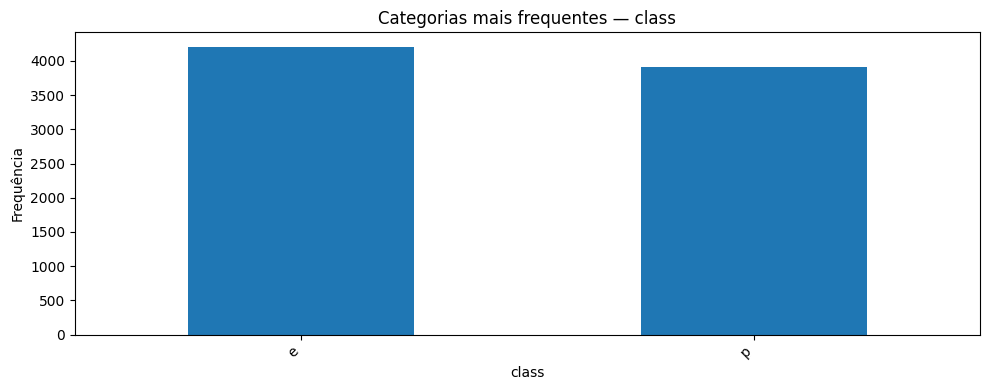

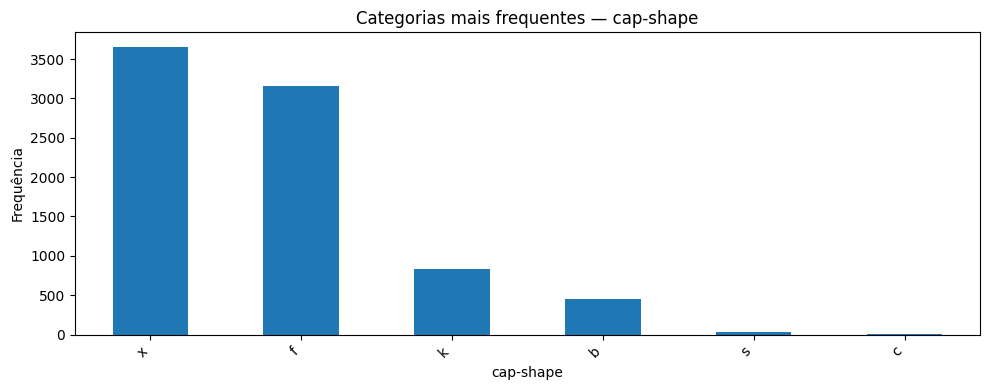

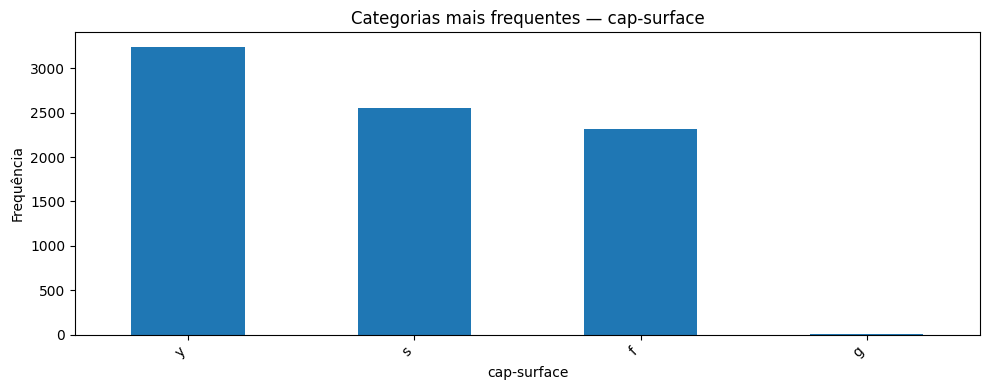

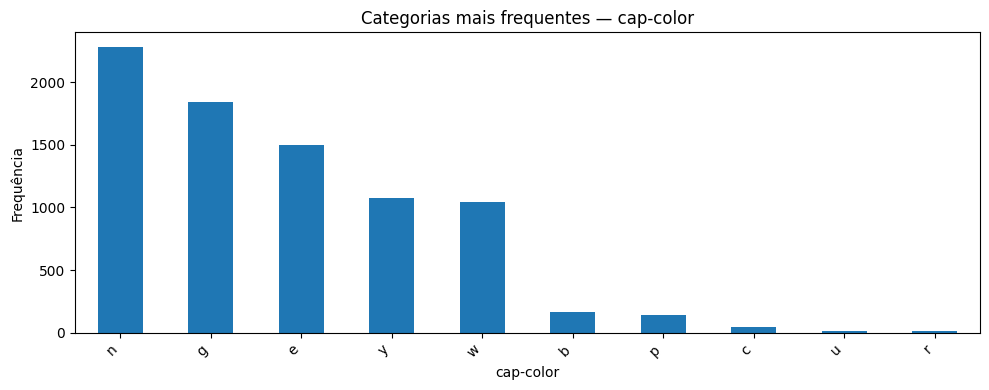

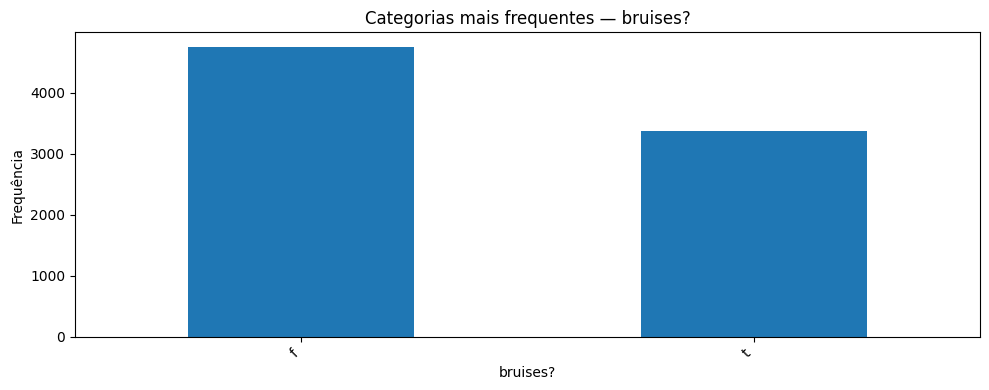

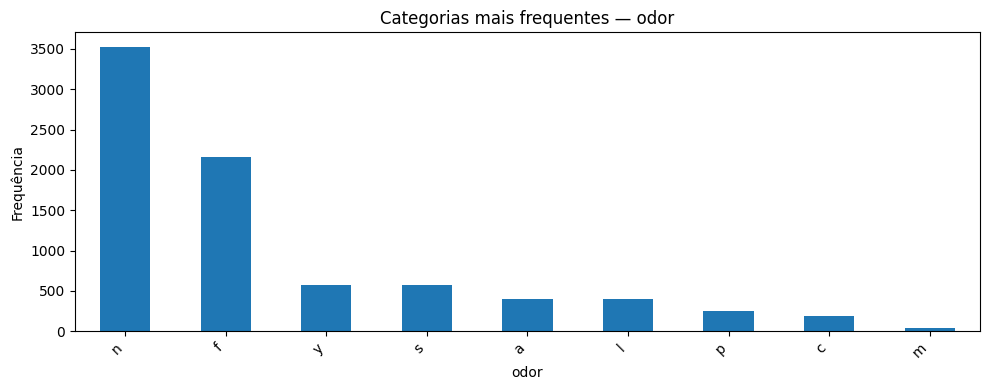

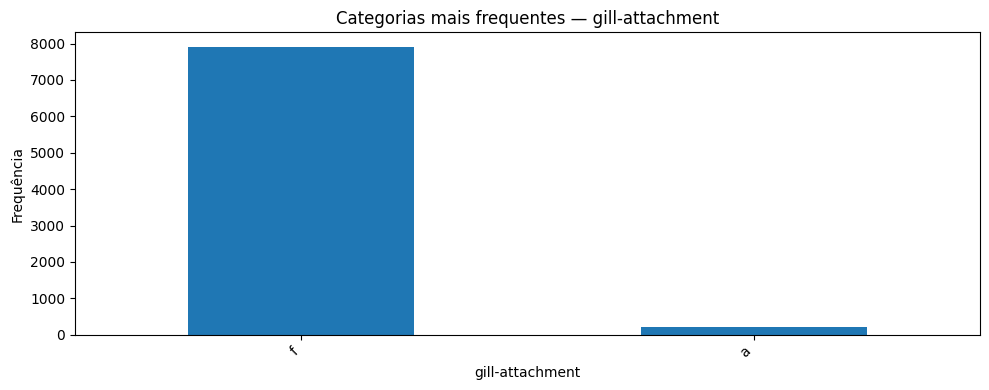

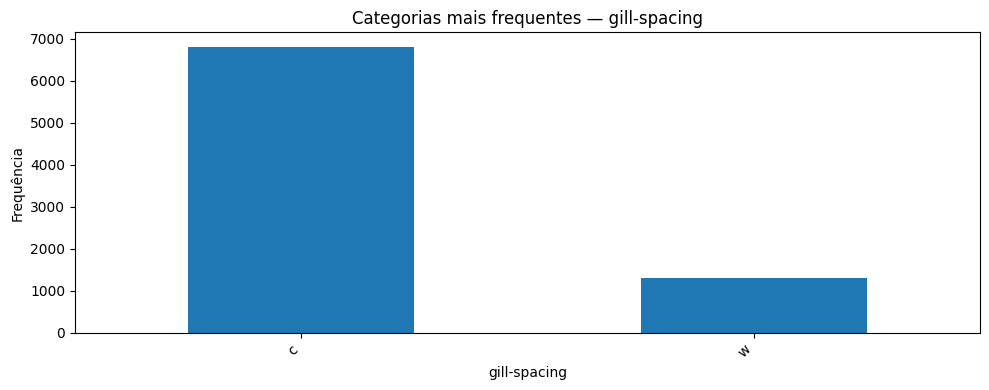

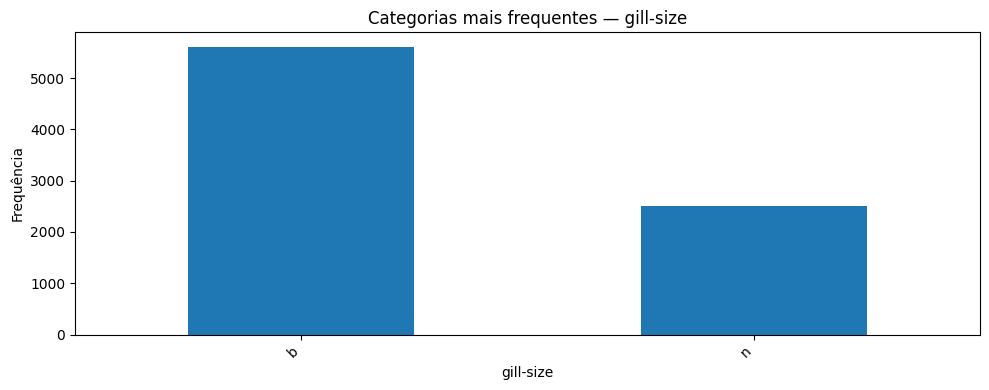

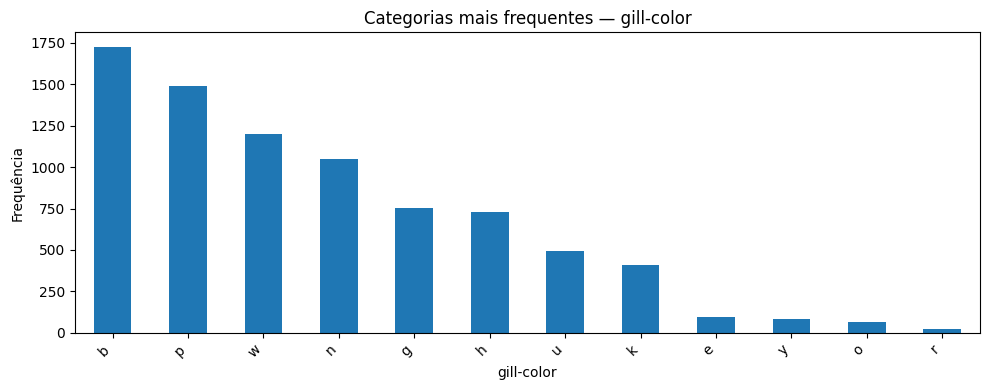

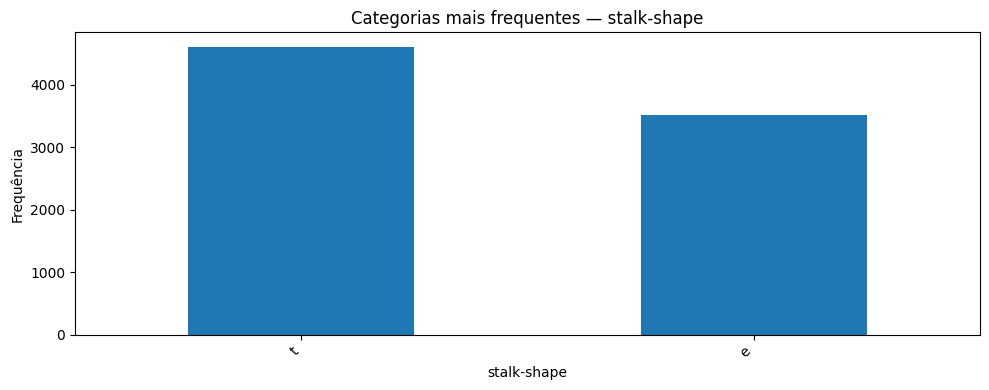

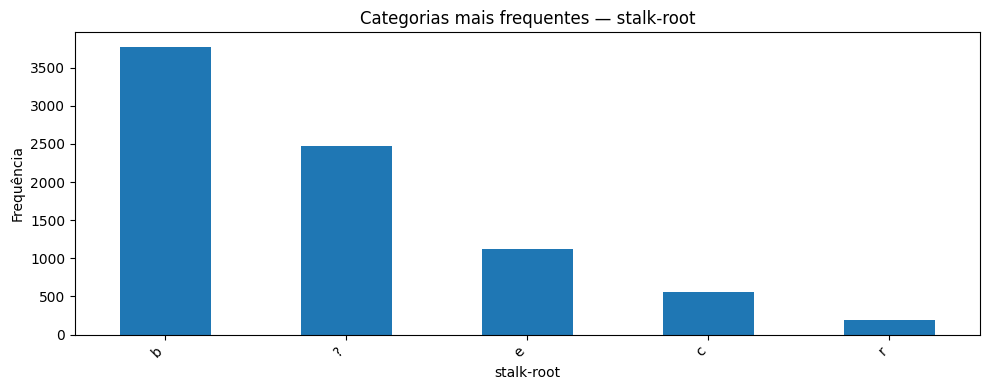

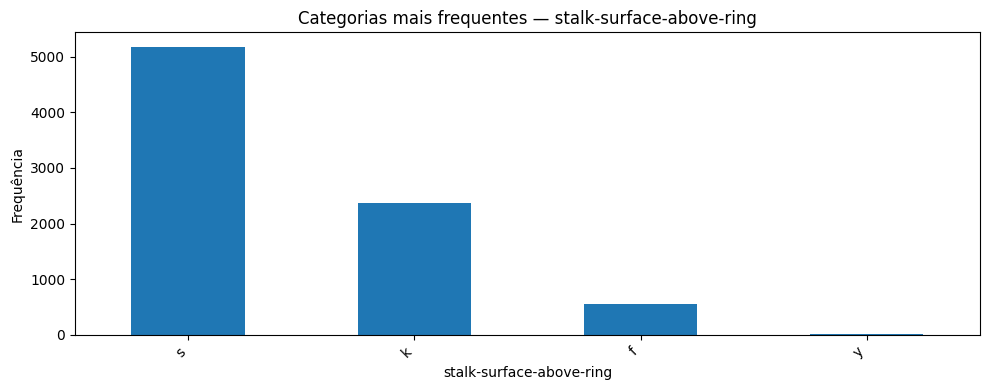

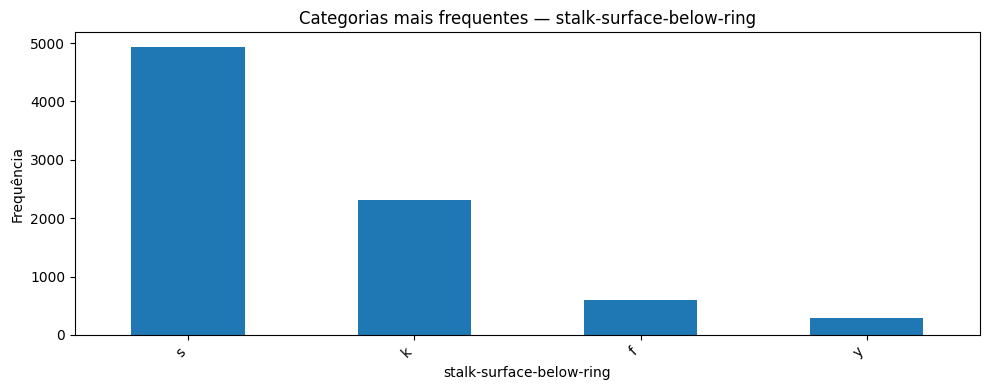

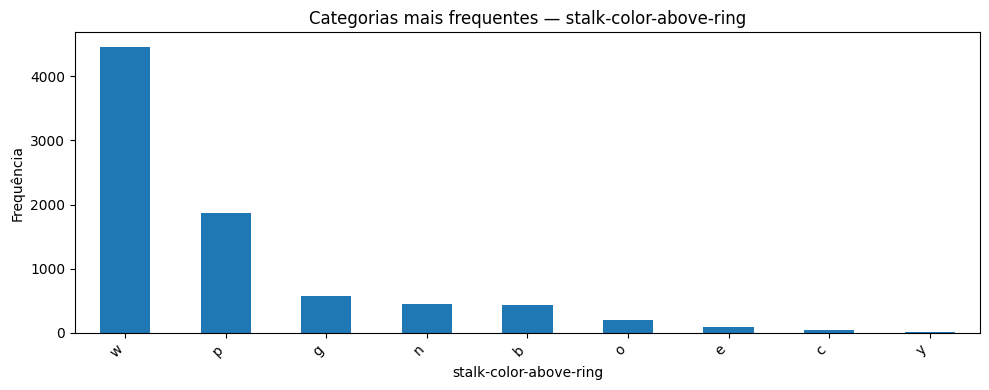

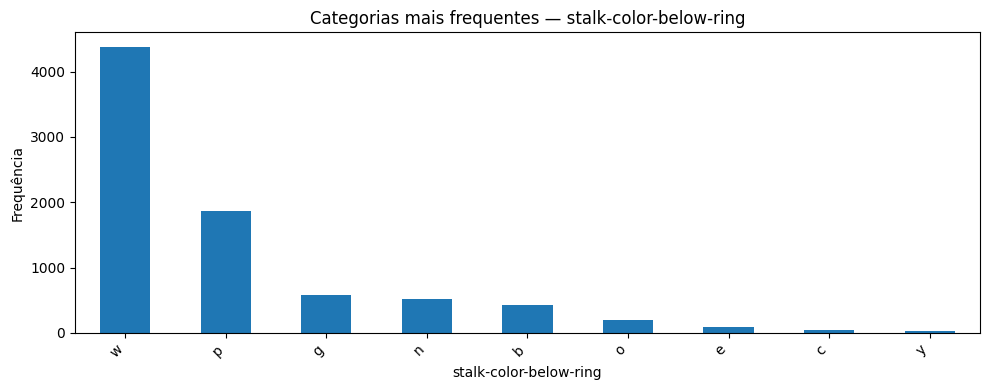

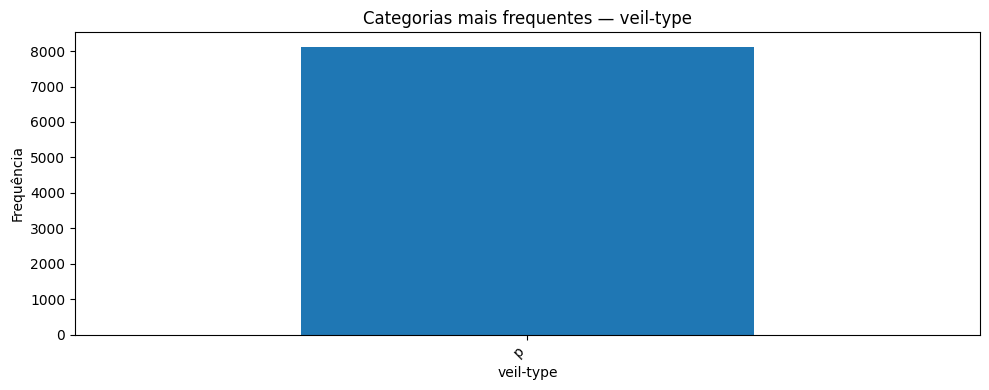

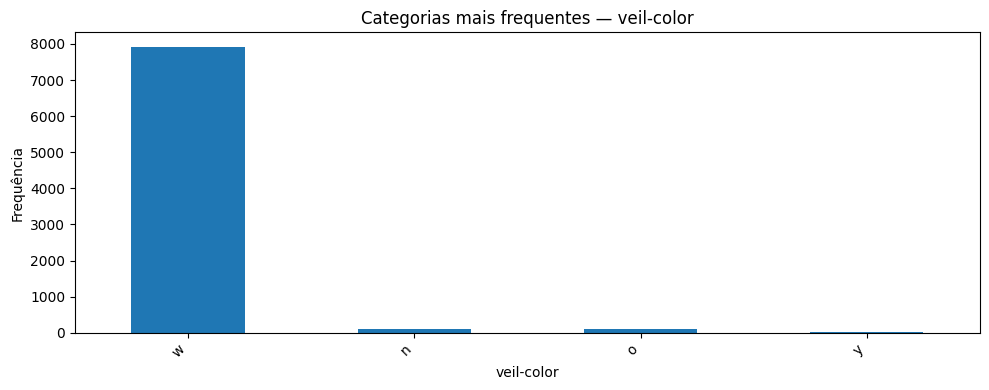

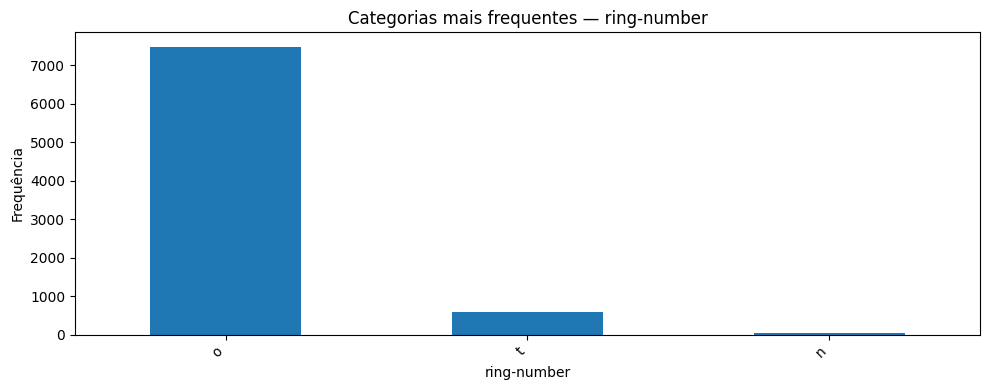

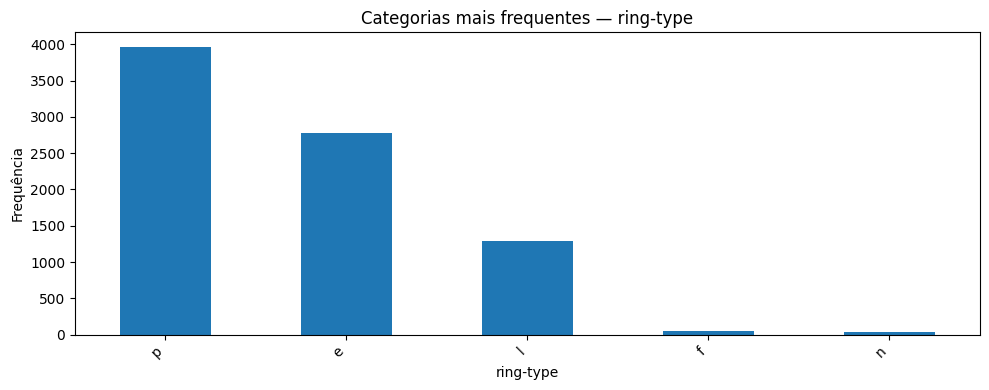

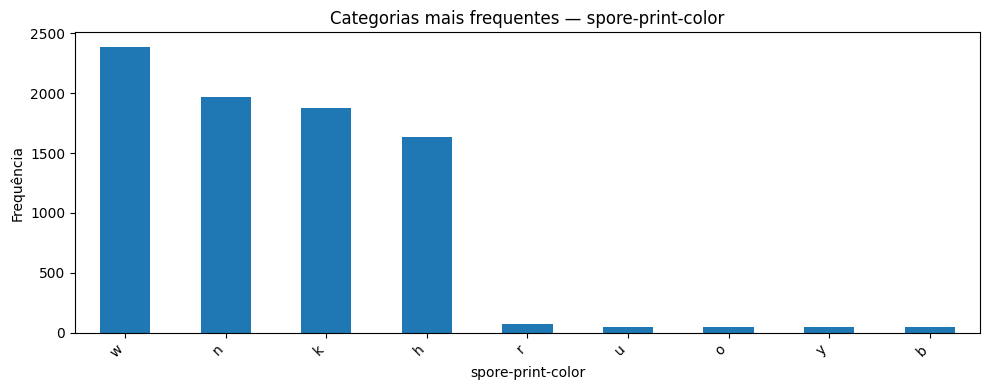

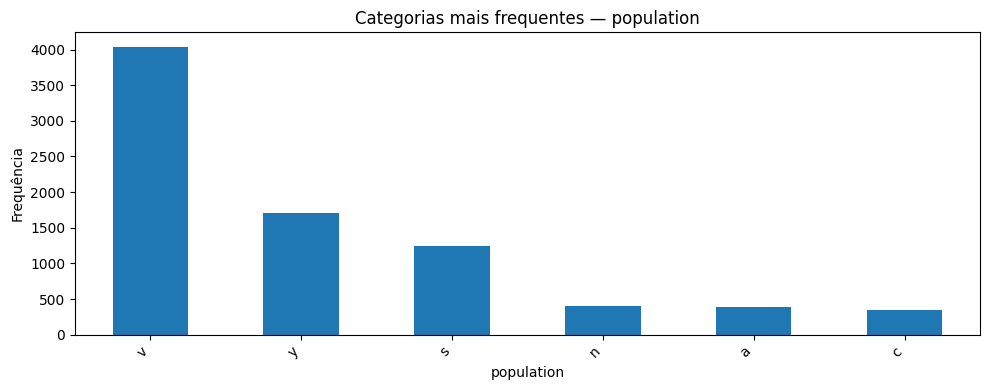

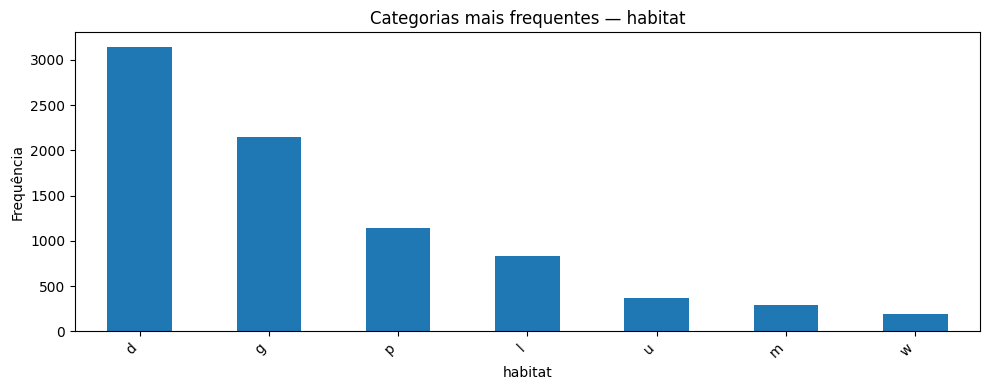

In [7]:
# Funções auxiliares para visualização exploratória
# Adapte as colunas e os gráficos ao dataset.

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Categorias mais frequentes — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for name in df.columns:
    plot_contagem_categorica(df, name)

## 2.2 Análise visual e principais insights
A análise de distribuição de frequências revelou padrões cruciais para a modelagem:

**1. Concentração e Desbalanceamento de Valores:**
- Atributos Dominantes: Variáveis como veil-color, ring-number, gill-attachment e veil-type apresentam um desbalanceamento extremo, onde uma única categoria detém quase a totalidade das instâncias. O caso mais crítico é o veil-type, que possui variância zero (100% de valores 'p'), tornando-o irrelevante para a mineração,
- Concentração Multimodal: Em spore-print-color e cap-color, há uma concentração clara em 4 ou 5 categorias principais (como branco e marrom), enquanto as demais cores são raras. Isso indica que as regras com maior Suporte virão dessas combinações cromáticas majoritárias.

**2. Categorias Raras e Riscos (Monitoramento e Avaliação):**
Observamos \"caudas longas\" em diversos atributos, como as cores de chapéu u (roxo) e r (verde), ou o habitat w (resíduos).

- Risco Identificado: Categorias muito raras podem gerar regras com Confiança de 100% de forma espúria (devido ao baixo número de amostras). Para mitigar isso, conforme nossa diretriz de Monitoramento, não confiaremos apenas na confiança, utilizando o Lift para validar se a associação é estatisticamente superior ao acaso.

**3. Padrões de Co-ocorrência Potenciais (Explicabilidade):**

Os atributos de textura, como stalk-surface-above-ring e stalk-surface-below-ring, apresentam distribuições muito similares, sugerindo uma forte correlação entre as partes do caule.
O atributo bruises (manchas) divide o dataset de forma equilibrada, o que é um excelente sinal para a Explicabilidade, pois é uma característica binária de fácil observação que pode servir como um divisor mestre nos antecedentes das regras.

**4. Tratamento de Incertezas:**
O atributo stalk-root possui uma categoria missing expressiva (2.480 ocorrências). A visualização confirma que esta não é uma falha pontual, mas uma característica estrutural de uma grande fatia das amostras. Tratá-la como uma categoria válida, e não como erro, preserva a integridade biológica do modelo.

In [10]:
# Verificação simples de duplicatas, nulos e possíveis identificadores

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    if df is None:
        print("Dataset não carregado.")
        return {}

    diagnostico = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": []
    }

    for col in df.columns:
        proporcao_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if proporcao_unicos > 0.95:
            diagnostico["colunas_possiveis_ids"].append(col)

    return diagnostico

# Exemplo de uso:
diagnostico = diagnostico_qualidade(df)
print(json.dumps(diagnostico, indent=2, ensure_ascii=False))

{
  "n_linhas": 8124,
  "n_colunas": 23,
  "n_duplicatas_exatas": 0,
  "colunas_com_nulos": [],
  "colunas_possiveis_ids": []
}


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
|---|---|---|---|
| Valores ausentes em `stalk-root` | 2.480 ocorrências encontradas de '?' (~30,5% da coluna). | MANTER | Justificamos pela diretriz de segurança, porque imputar a moda (como sugerido pela LLM Baseline) criaria artificialmente dados biológicos inexistentes. Manter o valor desconhecido permite que o modelo crie regras seguras de isolamento para casos em que o usuário não consiga identificar a raiz do estipe no campo. |
| Duplicatas | `df.duplicated().sum()` | Manter | Os dados encontram-se estruturalmente íntegros em suas combinações de características originais, representando espécimes independentes |
| Outliers | Gráficos de habitat, cap-shape e cap-color com barras mínimas. | MANTER | Em dados categóricos, "outliers" são categorias raras. Manteremos todas para não ignorar espécimes venenosos raros. |
| Atributos identificadores | Não se aplica | Manter | Não temos colunas possivelmente identificadoras |
| Atributos sensíveis | Não se aplica | Manter | Por se tratar de dados de cogumelos, não temos atributos sensíveis |
| Atributos de Variância Zero | Gráfico de veil-type com 100% de frequência em uma única categoria. | Remover | Atributos constantes não possuem poder discriminatório. |
| Baixa Variabilidade | Gráficos de veil-color e ring-number (predomínio > 90% de um valor). | MANTER | Embora desbalanceados, possuem variação mínima que pode ser crucial para regras de exceção ligadas à segurança |

### Observação sobre responsabilidade

As decisões de qualidade tomadas aqui reforçam a diretriz de Segurança e Explicabilidade. Ao optar por manter categorias raras e o dado "missing" de stalk-root, priorizamos a Explicabilidade e a segurança de assumir quando não sabemos de algo. A remoção de veil-type atende à eficiência técnica sem prejudicar a segurança ou ae xplicabilidade, pois um dado que nunca muda não ajuda a explicar por que um cogumelo é ou não venenoso. 

In [11]:
# Preparação final dos dados
# Esta função deve ser adaptada pelo grupo.
# Não use transformações automáticas sem justificar no texto.

def preparar_dados_final(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        raise ValueError("Dataset não carregado.")

    df_prep = df.copy()

    # 1. Remoção de duplicatas exatas, se justificado.
    # Podemos deixar, não tem duplicatas exatas.
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas sem variância (Atributos constantes)
    # Como vimos nos gráficos, 'veil-type' tem 100% de valores 'p' e deve sair.
    colunas_remover = ["veil-type"]
    df_prep = df_prep.drop(columns=[c for c in colunas_remover if c in df_prep.columns])

    # 3. Tratamento simples de nulos em variáveis numéricas.
    # Esta é uma estratégia genérica. Avalie se faz sentido para o dataset.
    for col in df_prep.select_dtypes(include=np.number).columns:
        if df_prep[col].isna().any():
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    # 4. Tratamento simples de nulos em variáveis categóricas.
    # Continuamos deixando os nulos (que seriam missing=?) com essa label de "?"

    # Tratamento de one hot encoding nas colunas preditoras
    colunas_preditoras = [c for c in df_prep.columns if c != 'class']
    
    df_prep = pd.get_dummies(df_prep, columns=colunas_preditoras, dtype=int)

    return df_prep

# Exemplo de uso:
df_prep = preparar_dados_final(df)
display(df_prep.head())
print(df_prep.shape)

,class,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,p,0,0,0,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,1,0
1,e,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,e,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,p,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,e,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0


(8124, 117)


## 2.4 Justificativa da preparação final

* **Colunas removidas:** Foi removida exclusivamente a coluna `veil-type` (tipo de véu). Como demonstrado na análise visual, 100% das 8.124 instâncias apresentavam o mesmo valor (`p`), configurando um cenário de variância zero. Mantê-la adicionaria dimensionalidade inútil e violaria o princípio da parcimônia.
* **Tratamento de valores ausentes:** Os valores ausentes na coluna `stalk-root`, representados originalmente pelo caractere `?`, foram **preservados e mantidos como uma categoria explícita** (ex: "Desconhecido"). Não foi aplicada nenhuma técnica de imputação sintética ou remoção de linhas.
* **Transformações aplicadas (Codificação):** Foi aplicado o One-Hot Encoding em todas as 21 variáveis preditoras restantes. Dado que todos os atributos do *Mushroom Dataset* são estritamente nominais, esta abordagem é matematicamente correta, pois expande as categorias em colunas binárias independentes (0 ou 1), e evita que os algoritmos interpretem ordens de grandeza inexistentes. Não houve necessidade de normalização ou discretização, visto que a base não possui atributos numéricos contínuos. Categorias de baixa variabilidade (como em `veil-color` e `ring-number`) e "outliers" categóricos foram rigorosamente mantidas em sua forma pura para não apagar exceções biológicas raras.

* **Decisões vindas da Trilha Baseline (Trilha A):** A trilha A forneceu a estrutura inicial de leitura do arquivo e sugeriu uma abordagem genérica de codificação das variáveis para que os modelos pudessem rodar sem erros de sintaxe no Python. Mas não foi a que seguimos principalmente.
* **Decisões vindas da Trilha Guiada (Trilha B):** A trilha guiada introduziu a necessidade de olhar para além do código funcional, instigando o grupo a avaliar os impactos das transformações sob a ótica das diretrizes de **Segurança** e **Explicabilidade**. Ela sugeriu uma postura mais cautelosa em relação a dados faltantes e desbalanceamentos severos.
* **Decisões próprias do grupo:** Nós decidimos manter integralmente as categorias de baixa frequência (outliers de habitat e cor) em vez de agrupá-las em uma categoria "outros", garantindo que espécimes venenosos raros continuem mapeados detalhadamente.
* **Descarte da Imputação por Moda:** A LLM da Trilha Baseline sugeriu preencher os valores ocultos (`?`) de `stalk-root` utilizando a moda da coluna. O grupo **rejeitou e corrigiu** esta orientação. Injetar a moda em mais de 30% de uma coluna micológica criaria correlações biológicas falsas e perigosas, podendo induzir o modelo a classificar um cogumelo fatal como seguro. Tratar o "desconhecido" como uma categoria legítima ensina o modelo a ser defensivo quando faltam dados.
* **Descarte de Ordinal/Label Encoding:** Em interações preliminares, a LLM sugeriu o uso de *Label Encoding* para simplificar a matriz. O grupo **rejeitou** a proposta, pois atribuir números sequenciais (1, 2, 3...) a variáveis nominais criaria uma falsa hierarquia matemática que distorceria os pesos de modelos lineares e as quebras das árvores de decisão, quebrando a **Transparência** do processo.
* **Omissão de Variância Zero:** As soluções automatizadas das LLMs inicialmente ignoraram a coluna `veil-type`. O grupo identificou visualmente a variância zero e efetuou a remoção manual para limpar o ruído estrutural dos dados.

In [ ]:
# Preparações específicas por tipo de tarefa
# Use apenas o bloco correspondente ao TASK_TYPE do trabalho.

from typing import List, Tuple, Optional


def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> List[List[str]]:
    """Gera transações para mineração de padrões frequentes a partir de uma coluna textual."""
    transacoes = []

    for valor in df[coluna].dropna():
        itens = [item.strip().lower() for item in str(valor).split(separador) if item.strip()]
        if itens:
            transacoes.append(itens)

    return transacoes


def preparar_matriz_modelagem(df: pd.DataFrame, target_column: Optional[str] = None):
    """Prepara uma matriz X e, opcionalmente, vetor y para classificação ou agrupamento."""
    df_model = df.copy()

    if target_column is not None:
        y = df_model[target_column]
        X = df_model.drop(columns=[target_column])
    else:
        y = None
        X = df_model

    # Codificação one-hot simples para variáveis categóricas.
    # Em trabalhos finais, justificar se esta codificação é adequada.
    X = pd.get_dummies(X, drop_first=False)

    return X, y

# Exemplos de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# X, y = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)

# 3. Modeling

Nesta seção, o grupo deve implementar a solução final.

A modelagem final deve ser resultado de uma decisão crítica, não de simples cópia da LLM.

A seção deve deixar claro:

- quais algoritmos foram testados;
- quais parâmetros foram usados;
- por que esses algoritmos foram escolhidos;
- o que foi inspirado pela baseline;
- o que foi inspirado pela trilha guiada;
- o que foi corrigido ou decidido pelo grupo;
- como a implementação se relaciona às diretrizes de IA responsável.

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline | Sugestão guiada | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| Algoritmo(s) | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Preparação dos dados | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Parâmetros | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Métricas | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Estratégia de avaliação | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Cuidados de IA responsável | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |

### Síntese da decisão final

[DESCREVER A SOLUÇÃO FINAL E JUSTIFICAR POR QUE ELA FOI ESCOLHIDA]

A solução final não precisa ser idêntica à melhor resposta da LLM. Ela deve ser tecnicamente defensável e baseada em evidências.

In [ ]:
# Registro simples de experimentos
# Ajuda a manter rastreabilidade de parâmetros e resultados.

experimentos = []


def registrar_experimento(nome: str, algoritmo: str, parametros: dict, metricas: dict, observacoes: str = ""):
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro


def salvar_experimentos(caminho: str = os.path.join(OUTPUT_DIR, "experimentos.json")):
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False)
    print(f"Experimentos salvos em: {caminho}")

# Exemplo:
# registrar_experimento(
#     nome="teste_inicial",
#     algoritmo="Apriori",
#     parametros={"min_support": 0.05, "min_confidence": 0.6},
#     metricas={"n_regras": 100, "tempo_segundos": 1.23},
#     observacoes="Teste preliminar."
# )

## 3.2 Modelagem para padrões frequentes

Use esta seção se o TP atual for de mineração de padrões frequentes.

Caso o TP seja de agrupamento ou classificação, mantenha apenas como referência e utilize as seções correspondentes abaixo.

In [ ]:
# Modelagem para padrões frequentes: Apriori e FP-Growth
# Esta célula depende de mlxtend. Instale se necessário: pip install mlxtend


def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada. Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(df_transacoes, min_support=min_support, use_colnames=True)
    regras_apriori = association_rules(itemsets_apriori, metric="confidence", min_threshold=min_confidence)
    tempo_apriori = time.time() - inicio

    resultados["Apriori"] = {
        "itemsets": itemsets_apriori,
        "regras": regras_apriori,
        "tempo_segundos": tempo_apriori
    }

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(df_transacoes, min_support=min_support, use_colnames=True)
    regras_fpgrowth = association_rules(itemsets_fpgrowth, metric="confidence", min_threshold=min_confidence)
    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo_segundos": tempo_fpgrowth
    }

    return resultados


def resumir_padroes_frequentes(resultados):
    if resultados is None:
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo_segundos"], 4),
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# resultados_padroes = executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6)
# resumo_padroes = resumir_padroes_frequentes(resultados_padroes)
# display(resumo_padroes)

## 3.3 Modelagem para agrupamento

Use esta seção se o TP atual for de clusterização.

A avaliação de agrupamento deve considerar métricas internas, interpretação dos grupos e coerência com o problema. Não basta reportar o número de clusters.

In [ ]:
# Modelagem para agrupamento: K-Means e DBSCAN
# Adapte os algoritmos conforme a proposta do grupo.


def executar_agrupamento_basico(X: pd.DataFrame):
    try:
        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans, DBSCAN
        from sklearn.metrics import silhouette_score, davies_bouldin_score
    except ImportError:
        print("scikit-learn não está instalado.")
        return pd.DataFrame(), {}

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    resultados = []
    modelos = {}

    # K-Means com alguns valores de k como exemplo.
    for k in [2, 3, 4, 5]:
        inicio = time.time()
        modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = modelo.fit_predict(X_scaled)
        tempo = time.time() - inicio

        if len(set(labels)) > 1:
            sil = silhouette_score(X_scaled, labels)
            db = davies_bouldin_score(X_scaled, labels)
        else:
            sil = np.nan
            db = np.nan

        nome = f"KMeans_k{k}"
        modelos[nome] = modelo
        resultados.append({
            "modelo": nome,
            "n_clusters": len(set(labels)),
            "silhouette": sil,
            "davies_bouldin": db,
            "tempo_segundos": tempo
        })

    # DBSCAN com parâmetros de exemplo.
    inicio = time.time()
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    tempo = time.time() - inicio

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
    else:
        sil = np.nan
        db = np.nan

    modelos["DBSCAN"] = dbscan
    resultados.append({
        "modelo": "DBSCAN",
        "n_clusters": n_clusters,
        "silhouette": sil,
        "davies_bouldin": db,
        "tempo_segundos": tempo
    })

    return pd.DataFrame(resultados), modelos

# Exemplo de uso:
# X, _ = preparar_matriz_modelagem(df_prep, target_column=None)
# resultados_cluster, modelos_cluster = executar_agrupamento_basico(X)
# display(resultados_cluster)

## 3.4 Modelagem para classificação

Use esta seção se o TP atual for de classificação.

A avaliação deve usar uma separação adequada entre treino e teste ou validação cruzada, além de métricas coerentes com o problema, especialmente se houver desbalanceamento de classes.

In [ ]:
# Modelagem para classificação: exemplos com árvore, regressão logística e random forest
# Adapte os modelos conforme a proposta do grupo.


def executar_classificacao_basica(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2):
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import Pipeline
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    except ImportError:
        print("scikit-learn não está instalado.")
        return pd.DataFrame(), {}

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None
    )

    modelos = {
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),
        "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
    }

    resultados = []
    modelos_treinados = {}

    average = "weighted" if y.nunique() > 2 else "binary"

    for nome, modelo in modelos.items():
        inicio = time.time()
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        tempo = time.time() - inicio

        resultados.append({
            "modelo": nome,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average=average, zero_division=0),
            "recall": recall_score(y_test, y_pred, average=average, zero_division=0),
            "f1": f1_score(y_test, y_pred, average=average, zero_division=0),
            "tempo_segundos": tempo
        })

        modelos_treinados[nome] = modelo

    return pd.DataFrame(resultados), modelos_treinados

# Exemplo de uso:
# X, y = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)
# resultados_classificacao, modelos_classificacao = executar_classificacao_basica(X, y)
# display(resultados_classificacao)

## 3.5 Resultados da modelagem final

[INSERIR RESULTADOS EFETIVAMENTE OBTIDOS]

Inclua tabelas e comentários sobre:

- algoritmos executados;
- parâmetros usados;
- métricas obtidas;
- tempo de execução;
- estabilidade ou sensibilidade a parâmetros;
- qualidade dos padrões, clusters ou classificações;
- interpretabilidade dos resultados;
- relação com as diretrizes escolhidas.

### Interpretação técnica

[INSERIR INTERPRETAÇÃO]

Evite conclusões vagas. Exemplos de frases fracas:

- “O algoritmo foi bom.”
- “O resultado foi satisfatório.”
- “A LLM ajudou bastante.”

Prefira afirmações verificáveis:

- “O FP-Growth gerou o mesmo conjunto de itemsets que o Apriori, mas com menor tempo de execução neste dataset.”
- “O modelo de árvore teve desempenho inferior, mas permitiu interpretação mais direta das regras de decisão.”
- “O K-Means com k=3 apresentou melhor silhouette entre os valores testados, mas a interpretação dos clusters ainda é limitada.”

# 4. Evaluation

Nesta seção, o grupo deve avaliar a solução final de forma crítica.

A avaliação deve considerar:

- qualidade dos resultados;
- adequação ao problema de negócio;
- desempenho dos algoritmos;
- limitações dos dados;
- limitações da modelagem;
- influência real das LLMs;
- influência real das diretrizes de IA responsável;
- trade-offs observados.

## 4.1 Avaliação dos resultados finais

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os resultados são coerentes com o problema?
- Os padrões, clusters ou classificações têm interpretação útil?
- As métricas usadas são adequadas?
- Há sinais de overfitting, instabilidade ou resultado trivial?
- Os resultados dependem fortemente de parâmetros?
- As conclusões são sustentadas pelos dados?

### Limitações dos resultados

[DESCREVER LIMITAÇÕES]

Exemplos:

- dataset desbalanceado;
- atributos pouco informativos;
- ausência de variáveis importantes;
- muitos dados ausentes;
- limitações de escala;
- dificuldade de interpretar padrões numerosos ou redundantes.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Adequação ao problema | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Preparação dos dados | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Algoritmos escolhidos | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Métricas de avaliação | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Interpretabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Rastreabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Eficiência computacional | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão da comparação

[INSERIR CONCLUSÃO COMPARATIVA]

A conclusão deve deixar claro:

- o que a baseline acertou;
- o que a baseline ignorou;
- o que a trilha guiada melhorou;
- o que a trilha guiada ainda errou;
- o que o grupo decidiu implementar;
- por que a solução final é tecnicamente mais defensável.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 3] | Grupo | Implementada | [JUSTIFICAR] |

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |

> O grupo deve demonstrar que avaliou criticamente a LLM. Uma boa entrega não aceita automaticamente todas as recomendações geradas.

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| [DIRETRIZ 1] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |
| [DIRETRIZ 2] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |

### Discussão crítica

[INSERIR DISCUSSÃO]

Questões orientadoras:

- A diretriz influenciou apenas o texto ou também o pipeline técnico?
- Houve mudança em atributos, algoritmos, métricas ou interpretação?
- A diretriz melhorou a qualidade da solução?
- Houve custo adicional, perda de desempenho ou aumento de complexidade?
- Alguma diretriz foi difícil de operacionalizar? Por quê?

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Desempenho × interpretabilidade | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Privacidade × utilidade dos dados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Eficiência × qualidade dos resultados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Simplicidade × completude da análise | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Justiça/viés × disponibilidade de atributos | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |

### Síntese

[INSERIR SÍNTESE DOS TRADE-OFFS MAIS IMPORTANTES]

Nem todos os trade-offs serão aplicáveis a todos os trabalhos. Discuta apenas os que fizerem sentido para o dataset e para a tarefa.

# 5. Conclusão

[INSERIR CONCLUSÃO FINAL]

A conclusão deve retomar:

1. o objetivo do trabalho;
2. a solução final implementada;
3. os principais resultados obtidos;
4. as limitações da análise;
5. o papel das LLMs;
6. o efeito das diretrizes de IA responsável;
7. possíveis melhorias futuras.

## Exemplo de estrutura de conclusão

> Neste trabalho, investigamos [PROBLEMA] usando o dataset [DATASET] e aplicamos [TÉCNICA]. Após comparar as sugestões da LLM nas condições baseline e guiada, decidimos implementar [SOLUÇÃO FINAL]. Os resultados indicam que [SÍNTESE DOS RESULTADOS], com limitações relacionadas a [LIMITAÇÕES]. A explicitação das diretrizes de [DIRETRIZ 1] e [DIRETRIZ 2] contribuiu para [EFEITO CONCRETO], embora [TRADE-OFF OU LIMITAÇÃO].

> Substitua o exemplo por uma conclusão real, baseada nos resultados executados.

# 6. Checklist final da Fase 3

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] validação das restrições mínimas do dataset;
- [ ] Business Understanding consolidado;
- [ ] descrição clara do dataset;
- [ ] dicionário de dados;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] explicação de como as diretrizes influenciaram a solução final;
- [ ] Data Understanding com tabelas, gráficos e interpretação;
- [ ] Data Preparation com justificativa das decisões;
- [ ] modelagem final executada;
- [ ] parâmetros documentados;
- [ ] métricas adequadas à tarefa;
- [ ] resultados interpretados;
- [ ] comparação baseline × guiada × solução final;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] erros e limitações das LLMs;
- [ ] trade-offs discutidos;
- [ ] conclusão final baseada em evidências;
- [ ] referências utilizadas.

# 7. Referências

[INSERIR REFERÊNCIAS UTILIZADAS]

Inclua, quando aplicável:

- documentação do dataset;
- materiais da disciplina;
- documentação das bibliotecas;
- referências sobre CRISP-DM;
- referências sobre algoritmos utilizados;
- referências sobre IA responsável;
- artigos ou livros usados para embasar decisões técnicas.

> As referências devem apoiar decisões reais do trabalho. Evite listar referências que não foram usadas na análise.

# 8. Apêndice opcional — detalhes adicionais

Use esta seção para incluir materiais complementares que não cabem no corpo principal do notebook, por exemplo:

- tabelas extensas;
- resultados de experimentos secundários;
- variações de parâmetros;
- prompts resumidos da Fase 2, se o grupo julgar necessário;
- detalhes de implementação;
- análises adicionais não centrais.

> O apêndice não substitui as seções principais. Ele deve apenas complementar a argumentação.

In [ ]:
# Célula opcional para salvar uma versão resumida dos principais artefatos gerados
# Adapte conforme os objetos produzidos no notebook.

# Exemplos:
# resumo_padroes.to_csv(os.path.join(OUTPUT_DIR, "resumo_padroes.csv"), index=False)
# resultados_cluster.to_csv(os.path.join(OUTPUT_DIR, "resultados_cluster.csv"), index=False)
# resultados_classificacao.to_csv(os.path.join(OUTPUT_DIR, "resultados_classificacao.csv"), index=False)
# salvar_experimentos()

print("Use esta célula apenas após gerar os artefatos finais do trabalho.")